# CNNs with PyTorch

This notebook is a small, self-contained example of building and training a
**Convolutional Neural Network (CNN)** in PyTorch for image classification.

### Why CNNs?
A normal fully connected layer needs a huge number of parameters even for a
small image, because every pixel connects to every neuron. CNNs fix this using:
- **Sparse connections** — each neuron only looks at a small local patch of the image
- **Parameter sharing** — the same filter (kernel) slides across the whole image and is reused everywhere

This makes CNNs far more efficient, and lets them detect the same feature
(like an edge or a curve) no matter where it appears in the image.

We'll use the `digits` dataset from scikit-learn (8x8 grayscale images of
handwritten digits, 10 classes) since it's small and needs no download —
easy to run anywhere. The same code pattern works for MNIST / CIFAR-10 with
minor changes (just swap the dataset loading part).

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import numpy as np

torch.manual_seed(0)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cpu


## 1. Load and prepare the data

Each image is 8x8 pixels, single channel (grayscale). We reshape into
`(N, 1, 8, 8)` since PyTorch conv layers expect `(batch, channels, height, width)`.

In [2]:
digits = load_digits()
X = digits.images.astype(np.float32) / 16.0   # pixel values are 0-16, normalize to 0-1
y = digits.target.astype(np.int64)

X = X.reshape(-1, 1, 8, 8)   # (N, channels, H, W)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

X_train_t = torch.tensor(X_train)
y_train_t = torch.tensor(y_train)
X_test_t = torch.tensor(X_test)
y_test_t = torch.tensor(y_test)

train_ds = TensorDataset(X_train_t, y_train_t)
test_ds = TensorDataset(X_test_t, y_test_t)

train_loader = DataLoader(train_ds, batch_size=32, shuffle=True)
test_loader = DataLoader(test_ds, batch_size=64, shuffle=False)

print("Train size:", len(train_ds), " Test size:", len(test_ds))

Train size: 1437  Test size: 360


## 2. Look at a few sample images

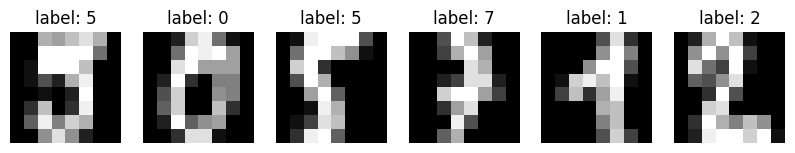

In [3]:
fig, axes = plt.subplots(1, 6, figsize=(10, 2))
for i, ax in enumerate(axes):
    ax.imshow(X_train[i][0], cmap="gray")
    ax.set_title(f"label: {y_train[i]}")
    ax.axis("off")
plt.show()

## 3. Define the CNN

Standard pattern: `Conv2D + ReLU -> Pool -> Conv2D + ReLU -> Pool -> Flatten -> Dense -> Softmax`
(the softmax is applied implicitly by `CrossEntropyLoss` during training).

In [4]:
class SimpleCNN(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()
        self.conv1 = nn.Conv2d(in_channels=1, out_channels=8, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(in_channels=8, out_channels=16, kernel_size=3, padding=1)
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)
        self.relu = nn.ReLU()

        # after two 2x2 poolings on an 8x8 image -> 2x2 feature map with 16 channels
        self.fc1 = nn.Linear(16 * 2 * 2, 32)
        self.fc2 = nn.Linear(32, num_classes)

    def forward(self, x):
        x = self.pool(self.relu(self.conv1(x)))   # 8x8 -> 4x4
        x = self.pool(self.relu(self.conv2(x)))   # 4x4 -> 2x2
        x = x.view(x.size(0), -1)                 # flatten
        x = self.relu(self.fc1(x))
        x = self.fc2(x)                           # logits (no softmax here)
        return x

model = SimpleCNN().to(device)
print(model)
total_params = sum(p.numel() for p in model.parameters())
print("Total trainable parameters:", total_params)

SimpleCNN(
  (conv1): Conv2d(1, 8, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2): Conv2d(8, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (relu): ReLU()
  (fc1): Linear(in_features=64, out_features=32, bias=True)
  (fc2): Linear(in_features=32, out_features=10, bias=True)
)
Total trainable parameters: 3658


## 4. Train the model

In [5]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)

num_epochs = 15
train_losses = []

for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)

        optimizer.zero_grad()
        logits = model(xb)
        loss = criterion(logits, yb)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * xb.size(0)

    epoch_loss = running_loss / len(train_ds)
    train_losses.append(epoch_loss)
    print(f"Epoch {epoch+1}/{num_epochs} - loss: {epoch_loss:.4f}")

Epoch 1/15 - loss: 2.2886
Epoch 2/15 - loss: 2.1659


Epoch 3/15 - loss: 1.7160
Epoch 4/15 - loss: 1.0661


Epoch 5/15 - loss: 0.6869
Epoch 6/15 - loss: 0.5160


Epoch 7/15 - loss: 0.4200
Epoch 8/15 - loss: 0.3600


Epoch 9/15 - loss: 0.3059
Epoch 10/15 - loss: 0.2737


Epoch 11/15 - loss: 0.2509
Epoch 12/15 - loss: 0.2204


Epoch 13/15 - loss: 0.2022
Epoch 14/15 - loss: 0.1853


Epoch 15/15 - loss: 0.1651


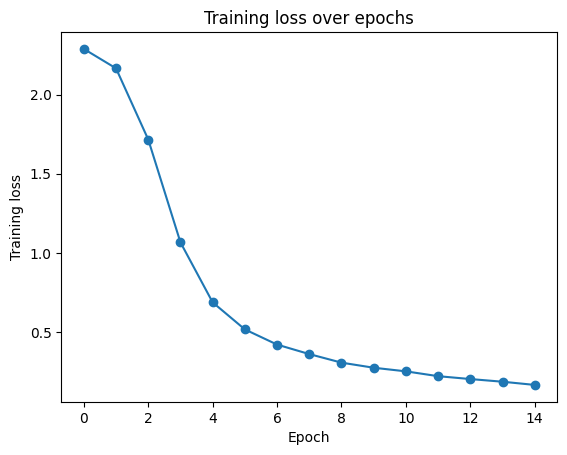

In [6]:
plt.plot(train_losses, marker="o")
plt.xlabel("Epoch")
plt.ylabel("Training loss")
plt.title("Training loss over epochs")
plt.show()

## 5. Evaluate on the test set

In [7]:
model.eval()
correct = 0
total = 0

with torch.no_grad():
    for xb, yb in test_loader:
        xb, yb = xb.to(device), yb.to(device)
        logits = model(xb)
        preds = logits.argmax(dim=1)
        correct += (preds == yb).sum().item()
        total += yb.size(0)

test_acc = correct / total
print(f"Test accuracy: {test_acc*100:.2f}%")

Test accuracy: 92.78%


## 6. Look at some predictions

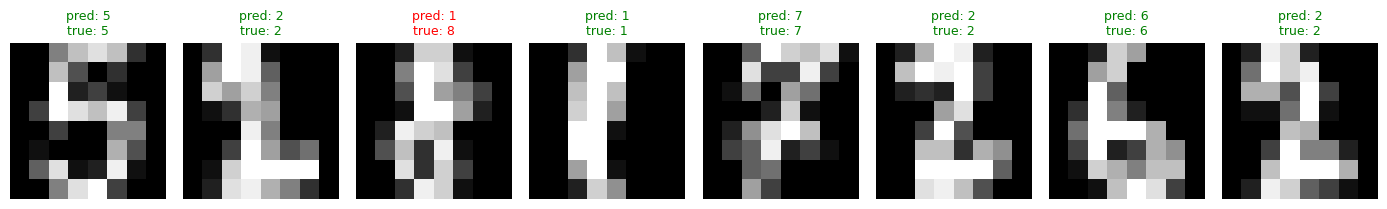

In [8]:
model.eval()
xb, yb = next(iter(test_loader))
xb_dev = xb.to(device)
with torch.no_grad():
    preds = model(xb_dev).argmax(dim=1).cpu()

fig, axes = plt.subplots(1, 8, figsize=(14, 2))
for i, ax in enumerate(axes):
    ax.imshow(xb[i][0], cmap="gray")
    color = "green" if preds[i] == yb[i] else "red"
    ax.set_title(f"pred: {preds[i].item()}\ntrue: {yb[i].item()}", color=color, fontsize=9)
    ax.axis("off")
plt.tight_layout()
plt.show()

## Summary / What we learned

- A CNN uses **convolution + pooling** layers to extract local features
  from an image, then a small fully-connected head to classify.
- Parameter sharing (same filter reused across the image) keeps the model
  small compared to a fully connected network on raw pixels.
- On this tiny 8x8 digits dataset the model reaches a high test accuracy in
  just a few epochs — for real datasets like MNIST (28x28) or CIFAR-10
  (32x32 color), the same architecture pattern applies, just with more
  filters / layers and a matching input shape.

### To try next
- Swap in `torchvision.datasets.MNIST` or `CIFAR10` for a bigger dataset
- Add `BatchNorm2d` after each conv layer
- Try a deeper network or add `Dropout` to reduce overfitting